In [1]:
import ignnition
import matplotlib.pyplot as plt

###  Normalize the input data

In [ ]:
import os
import tarfile
import json
import numpy as np
from tqdm import tqdm
from collections import defaultdict

# paths
train_dir = "dataTrain_few/train"
out_dir  = "dataTrain_few/train_clean"
os.makedirs(out_dir, exist_ok=True)

# exact features to skip normalization (case-insensitive)
EXCLUDE_KEYS = {
    "node_id", "srcnode", "device_id", "source_node", "device_paired",
    "band_id", "src_node_flow", "dst_node_flow", "dscp_tag_dec",
    "traffic_type_mapped", "nflow_id"
}


In [ ]:
def is_excluded(path):
    # check last token of path against EXCLUDE_KEYS (case-insensitive)
    last = path.split(".")[-1].lower()
    return last in EXCLUDE_KEYS

def collect_numeric_values(obj, stats, path=""):
    """
    - obj: Python object from json.load()
    - stats: dict mapping 'path' -> list of numeric values (will append)
    - path: dot-separated key path
    This function appends numeric values found in obj to stats[path_key].
    For numeric lists, it records each index separately as path + f".{i}".
    """
    if isinstance(obj, dict):
        for k, v in obj.items():
            new_path = k if path=="" else path + "." + k
            collect_numeric_values(v, stats, new_path)
    elif isinstance(obj, list):
        # if list of numbers -> record per-index feature
        if all(isinstance(x, (int, float)) or x is None for x in obj):
            for i, val in enumerate(obj):
                if val is None: 
                    continue
                key_i = f"{path}.{i}"
                if not is_excluded(key_i):
                    if isinstance(val, (int, float)) and not (isinstance(val, float) and np.isnan(val)):
                        stats[key_i].append(float(val))
        else:
            # list of dicts or nested -> walk each element using index in path
            for i, elem in enumerate(obj):
                new_path = f"{path}[{i}]"
                collect_numeric_values(elem, stats, new_path)
    elif isinstance(obj, (int, float)):
        if obj is None or (isinstance(obj, float) and np.isnan(obj)):
            return
        # only record if last key not excluded
        if not is_excluded(path):
            stats[path].append(float(obj))
    # else: strings, bools ignored


In [ ]:
from collections import defaultdict
import math

def build_stats_from_tars(train_dir):
    stats = defaultdict(list)  # path -> list of values
    tar_files = [os.path.join(train_dir, f) for f in os.listdir(train_dir) if f.endswith(".tar.gz") or f.endswith(".tar")]
    for tar_path in tqdm(tar_files, desc="Scanning tar files for stats"):
        with tarfile.open(tar_path, "r:*") as tar:
            for member in tar.getmembers():
                if not member.isfile(): 
                    continue
                if not member.name.lower().endswith(".json"):
                    continue
                f = tar.extractfile(member)
                if f is None:
                    continue
                try:
                    data = json.load(f)
                except Exception as e:
                    print("Could not load JSON", member.name, "in", tar_path, ":", e)
                    continue
                collect_numeric_values(data, stats, path="")
    # compute mean/std/min/max
    norm_stats = {}
    for key, values in stats.items():
        if len(values) == 0:
            continue
        arr = np.array(values, dtype=float)
        mean = float(np.nanmean(arr))
        std  = float(np.nanstd(arr, ddof=0))  # population std
        mn   = float(np.nanmin(arr))
        mx   = float(np.nanmax(arr))
        norm_stats[key] = {"count": len(arr), "mean": mean, "std": std, "min": mn, "max": mx}
    return norm_stats

# run and save stats
norm_stats = build_stats_from_tars(train_dir)
# save to JSON for reuse
with open(os.path.join(out_dir, "normalization_stats.json"), "w") as fh:
    json.dump(norm_stats, fh, indent=2)
print("Saved normalization stats for", len(norm_stats), "features.")


In [ ]:
def normalize_value_by_key(value, key_path, norm_stats, method="zscore"):
    """
    Normalize single numeric value based on norm_stats dict.
    If std is zero, returns 0. For missing key in norm_stats, returns original value.
    """
    if key_path not in norm_stats:
        return value
    s = norm_stats[key_path]
    mean, std, mn, mx = s["mean"], s["std"], s["min"], s["max"]
    if value is None or (isinstance(value, float) and np.isnan(value)):
        value = mean
    if method == "zscore":
        if std == 0:
            return 0.0
        return float((value - mean) / std)
    else:  # minmax
        denom = (mx - mn) if (mx - mn) != 0 else 1.0
        return float((value - mn) / denom)

def normalize_json_object(obj, norm_stats, path=""):
    """Return a new object with numeric leaves normalized."""
    if isinstance(obj, dict):
        return {k: normalize_json_object(v, norm_stats, path + ("." + k if path else k)) for k, v in obj.items()}
    elif isinstance(obj, list):
        # numeric list?
        if all(isinstance(x, (int, float)) or x is None for x in obj):
            out = []
            for i, val in enumerate(obj):
                key_i = f"{path}.{i}"
                if is_excluded(key_i):
                    out.append(val)
                else:
                    v = mean = None
                    # if val is None or nan -> replaced in normalize_value_by_key
                    out.append(normalize_value_by_key(val, key_i, norm_stats, method="zscore"))
            return out
        else:
            out = []
            for i, elem in enumerate(obj):
                new_path = f"{path}[{i}]" if path else f"[{i}]"
                out.append(normalize_json_object(elem, norm_stats, new_path))
            return out
    elif isinstance(obj, (int, float)):
        if is_excluded(path):
            return obj
        return normalize_value_by_key(obj, path, norm_stats, method="zscore")
    else:
        return obj  # strings, booleans remain unchanged

def apply_normalization_to_tars(train_dir, out_dir, norm_stats):
    tar_files = [os.path.join(train_dir, f) for f in os.listdir(train_dir) if f.endswith(".tar.gz") or f.endswith(".tar")]
    for tar_path in tqdm(tar_files, desc="Normalizing and saving cleaned JSONs"):
        base = os.path.basename(tar_path).replace(".tar.gz", "").replace(".tar", "")
        with tarfile.open(tar_path, "r:*") as tar:
            for member in tar.getmembers():
                if not member.isfile(): 
                    continue
                if not member.name.lower().endswith(".json"):
                    continue
                f = tar.extractfile(member)
                if f is None:
                    continue
                try:
                    data = json.load(f)
                except Exception as e:
                    print("Could not load JSON", member.name, "in", tar_path, ":", e)
                    continue
                # normalize
                data_clean = normalize_json_object(data, norm_stats, path="")
                # safe output filename
                member_base = os.path.basename(member.name)
                out_name = f"{base}__{member_base}_cleaned.json"
                out_path = os.path.join(out_dir, out_name)
                with open(out_path, "w") as fh:
                    json.dump(data_clean, fh)
    print("All cleaned JSONs written to", out_dir)

# run pass 2
with open(os.path.join(out_dir, "normalization_stats.json"), "r") as fh:
    norm_stats = json.load(fh)
apply_normalization_to_tars(train_dir, out_dir, norm_stats)


### Train the model

In [35]:
model = ignnition.create_model(model_dir='./')


Processing the described model...
---------------------------------------------------------------------------



In [36]:
model.computational_graph()
model.train_and_validate()

Creating the GNN model...
---------------------------------------------------------------------------

Generating the computational graph... 
---------------------------------------------------------------------------

Starting the training and validation process...
---------------------------------------------------------------------------

Your model is running on 1 CPU.


Epoch 1/5
5000/5000 [==============================] - 299s 57ms/step - loss: 10443.6855 - mean_absolute_error: 6.7292 - val_loss: 0.1203 - val_mean_absolute_error: 0.1804


Epoch 2/5
5000/5000 [==============================] - 282s 56ms/step - loss: 177.3120 - mean_absolute_error: 0.3029 - val_loss: 6.6160 - val_mean_absolute_error: 0.2636


Epoch 3/5
5000/5000 [==============================] - 281s 56ms/step - loss: 21.3229 - mean_absolute_error: 0.2503 - val_loss: 0.1252 - val_mean_absolute_error: 0.2149


Epoch 4/5
5000/5000 [==============================] - 277s 55ms/step - loss: 0.1247 - mean_absolute_error: 0.1873 - val_loss: 0.1036 - val_mean_absolute_error: 0.1752


Epoch 5/5
5000/5000 [==============================] - 289s 58ms/step - loss: 10.6594 - mean_absolute_error: 0.1907 - val_loss: 0.1041 - val_mean_absolute_error: 0.1856


For tensorboard, copy to the shell **tensorboard --logdir ./**

#### Testing

In [2]:
model = ignnition.create_model(model_dir='./')


Processing the described model...
---------------------------------------------------------------------------



In [3]:
model.evaluate()

Creating the GNN model...
---------------------------------------------------------------------------

Restoring saved model from ./CheckPoint/experiment_2025_09_30_16_35_16/ckpt/weights.04-0.125


Starting to make evaluations...
---------------------------------------------------------

1000/1000 [==============================] - 53s 40ms/step - loss: 0.1036 - mean_absolute_error: 0.1752


{'loss': 0.10360740125179291, 'mean_absolute_error': 0.17517653107643127}

In [4]:
prediction=model.predict()


Starting to make the predictions...
---------------------------------------------------------



In [7]:
convert_to_np = []
for elem in prediction:
    convert_to_np.append(elem.numpy())
'''
    with open('Results.pkl', 'wb') as f:
        pickle.dump(convert_to_np, f)
'''

"\n    with open('Results.pkl', 'wb') as f:\n        pickle.dump(convert_to_np, f)\n"

### Post training analysis

In [10]:
mean_delay_per_simulation=[a.mean() for a in convert_to_np]

In [30]:
# Flatten all arrays into a single 1D array
mean_delay_preds = np.concatenate(convert_to_np)

single DataFrame containing all flows from all .tar files in the evaluation set, including both features and labels.

In [61]:
import os, tarfile, json
import pandas as pd

eval_dir = "dataTrain_few/eval"   # or your evaluation dataset folder
import tarfile
import json
import pandas as pd
from pathlib import Path

dataeval_path = Path("dataTrain_few/eval")
records = []

# Iterate over all .tar or .tar.gz files
for tar_file in dataeval_path.glob("*.tar*"):
    with tarfile.open(tar_file, "r:*") as tar:
        # Find the JSON file inside
        json_members = [m for m in tar.getmembers() if m.name.endswith("data.json")]
        for member in json_members:
            f = tar.extractfile(member)
            if f:
                graph_list = json.load(f)  # list of graphs
                for g_idx, graph in enumerate(graph_list):
                    for node in graph["nodes"]:
                        if node["entity"] == "flow":
                            features = {k: v for k, v in node.items() if k not in ["labels", "entity", "id"]}
                            labels = node.get("labels", {})
                            records.append({
                                "graph_id": g_idx,
                                **features,
                                **labels
                            })

# Convert to DataFrame
df_flows = pd.DataFrame(records)
df_flows.head(5)


,graph_id,src_node_flow,dst_node_flow,traffic_type,dscp_tag,traffic_type_mapped,dscp_tag_dec,duration_p0,duration_p25,duration_p50,...,mean_tx_bit_rate_mean,mean_tx_bit_rate_std,mean_tx_bit_rate_max,mean_tx_bit_rate_min,mean_delay,mean_jitter,mean_tx_bit_rate,bandwidth_pct_%,nflow_id,traversed_links
0,0,0,1,FTP,AF31,3,26,17.4029,17.584000,17.76510,...,0.009661,0.002583,0.012244,0.007077,1.051035,0.113627,0.019322,9.594435,2,[3]
1,0,0,1,FTP,AF41,3,34,16.7765,16.796175,16.81585,...,0.005661,0.001120,0.006781,0.004541,1.923034,1.832459,0.011322,1.806511,2,[1]
2,0,0,1,FTP,BF,3,0,-0.5000,4.082900,19.21905,...,0.002745,0.004685,0.015056,0.000000,0.698432,0.030470,0.038435,6.132445,14,[1]
3,0,0,1,FTP,EF,3,46,-0.5000,-0.500000,-0.50000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2,[1]
4,0,0,1,GAMING,AF31,2,26,18.9141,18.914100,18.91410,...,0.011349,0.000000,0.011349,0.011349,0.952036,0.096637,0.011349,5.635540,1,[3]


In [62]:
df_flows.mean_delay

0       1.051035
1       1.923034
2       0.698432
3       0.000000
4       0.952036
          ...   
3646    0.226290
3647    0.214622
3648    0.214756
3649    0.225996
3650    0.234635
Name: mean_delay, Length: 3651, dtype: float64

In [65]:
df_flows.columns

Index(['graph_id', 'src_node_flow', 'dst_node_flow', 'traffic_type',
       'dscp_tag', 'traffic_type_mapped', 'dscp_tag_dec', 'duration_p0',
       'duration_p25', 'duration_p50',
       ...
       'mean_tx_bit_rate_std', 'mean_tx_bit_rate_max', 'mean_tx_bit_rate_min',
       'mean_delay', 'mean_jitter', 'mean_tx_bit_rate', 'bandwidth_pct_%',
       'nflow_id', 'traversed_links', 'mean_delay_pred'],
      dtype='object', length=104)

In [ ]:
import numpy as np
import pandas as pd

# Suppose convert_to_np is a list of arrays, one array per sample
# e.g., convert_to_np = [array([0.1, 0.2]), array([0.15, 0.25, 0.3]), ...]

# Flatten all arrays into a single 1D array
mean_delay_preds = np.concatenate(convert_to_np)

# Make sure the length matches df_flows
assert len(mean_delay_preds) == len(df_flows), "Length mismatch!"

# Add as a new column
df_flows["mean_delay_pred"] = mean_delay_preds

# Check
print(df_flows[["nflow_id", "mean_delay", "mean_delay_pred"]].head(20))


    nflow_id  mean_delay  mean_delay_pred
0          2    1.051035         1.221284
1          2    1.923034         1.622904
2         14    0.698432         1.055941
3          2    0.000000         0.111782
4          1    0.952036         0.862469
5          7    1.630100         1.221689
6          1    0.764973         1.140592
7          1    0.882378         0.991781
8         21    0.882066         1.160916
9          3    4.202436         1.212342
10         3    0.804496         0.955414
11         3    0.838819         0.726048
12         2    0.883221         0.469512
13         2    2.582253         2.028626
14         2    0.893689         0.824047
15        14    0.708823         0.697811
16         2    0.221009         0.203575
17         2    0.249101         0.207771
18         4    0.217304         0.201552
19         1    0.209613         0.199573


In [69]:
import numpy as np

# Absolute error
df_flows["abs_error_mean_delay"] = np.abs(df_flows["mean_delay"] - df_flows["mean_delay_pred"])

# Squared error
df_flows["sq_error_mean_delay"] = (df_flows["mean_delay"] - df_flows["mean_delay_pred"])**2


In [71]:
# By traffic type
traffic_summary = df_flows.groupby("traffic_type")["abs_error_mean_delay"].agg(["mean", "std", "count"])
print("Traffic summary MAE")
print(traffic_summary)

# By DSCP
dscp_summary = df_flows.groupby("dscp_tag")["abs_error_mean_delay"].agg(["mean", "std", "count"])
print("dscp summary MAE")
print(dscp_summary)


Traffic summary MAE
                  mean       std  count
traffic_type                           
FTP           0.206536  0.447173    860
GAMING        0.166707  0.255536    896
VIDEO         0.163775  0.260829    939
VOIP          0.157789  0.255086    956
dscp summary MAE
              mean       std  count
dscp_tag                           
AF31      0.190714  0.363946    897
AF41      0.213856  0.444871    912
BF        0.152435  0.190912    960
EF        0.135122  0.150910    882


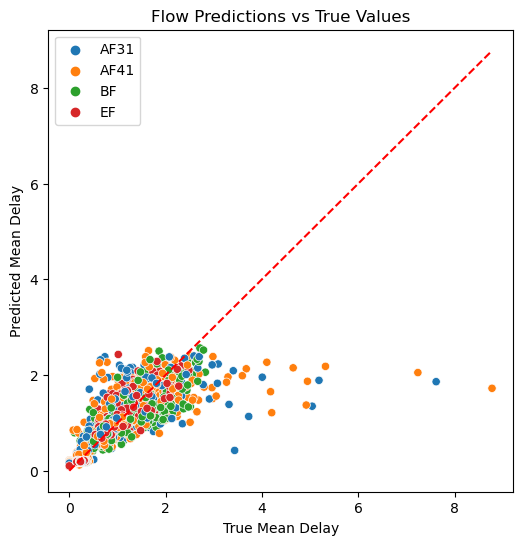

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: true vs predicted
plt.figure(figsize=(6,6))
sns.scatterplot(x="mean_delay", y="mean_delay_pred", hue="dscp_tag", data=df_flows)
plt.plot([df_flows["mean_delay"].min(), df_flows["mean_delay"].max()],
         [df_flows["mean_delay"].min(), df_flows["mean_delay"].max()], "r--")  # y=x line
plt.xlabel("True Mean Delay")
plt.ylabel("Predicted Mean Delay")
plt.title("Flow Predictions vs True Values")
plt.legend()
plt.show()


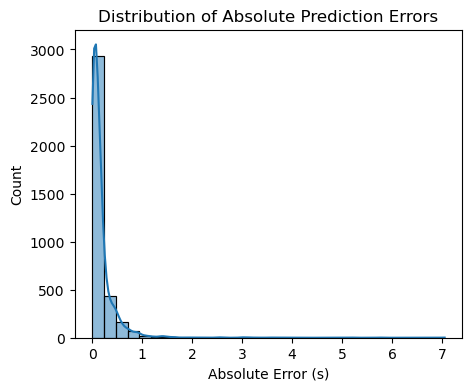

In [74]:
plt.figure(figsize=(5,4))
sns.histplot(df_flows["abs_error_mean_delay"], bins=30, kde=True)
plt.title("Distribution of Absolute Prediction Errors")
plt.xlabel("Absolute Error (s)")
plt.ylabel("Count")
plt.show()


In [76]:
agg_analysis = df_flows.groupby(["traffic_type", "dscp_tag"]).agg({
    "mean_delay": "mean",
    "mean_delay_pred": "mean",
    "abs_error_mean_delay": "mean"
}).reset_index()

print(agg_analysis)


   traffic_type dscp_tag  mean_delay  mean_delay_pred  abs_error_mean_delay
0           FTP     AF31    0.693823         0.683602              0.217553
1           FTP     AF41    0.784823         0.755314              0.272515
2           FTP       BF    0.799501         0.796029              0.148832
3           FTP       EF    0.718272         0.804701              0.191757
4        GAMING     AF31    0.581772         0.554040              0.216898
5        GAMING     AF41    0.578266         0.596918              0.153141
6        GAMING       BF    0.688866         0.614120              0.160712
7        GAMING       EF    0.654137         0.662695              0.140545
8         VIDEO     AF31    0.688070         0.733360              0.143234
9         VIDEO     AF41    0.785339         0.673660              0.226952
10        VIDEO       BF    0.705408         0.658871              0.155158
11        VIDEO       EF    0.645818         0.691287              0.129806
12         V

In [77]:
corr = df_flows[["mean_delay", "mean_delay_pred"]].corr()
print("Correlation:\n", corr)


Correlation:
                  mean_delay  mean_delay_pred
mean_delay         1.000000         0.840853
mean_delay_pred    0.840853         1.000000


### Catalogue de config QoS + Lien

In [79]:
model = ignnition.create_model(model_dir='./')
model.evaluate()
prediction=model.predict()
convert_to_np = []
for elem in prediction:
    convert_to_np.append(elem.numpy())



Processing the described model...
---------------------------------------------------------------------------

Creating the GNN model...
---------------------------------------------------------------------------

Restoring saved model from ./CheckPoint/experiment_2025_09_30_16_35_16/ckpt/weights.04-0.125


Starting to make evaluations...
---------------------------------------------------------

1000/1000 [==============================] - 50s 44ms/step - loss: 0.1036 - mean_absolute_error: 0.1752

Starting to make the predictions...
---------------------------------------------------------



Extract flows

In [41]:
import os, tarfile, json
import pandas as pd

eval_dir = "dataTest/train"   # or your evaluation dataset folder
import tarfile
import json
import pandas as pd
from pathlib import Path

dataeval_path = Path(eval_dir)
records = []

# Iterate over all .tar or .tar.gz files
for tar_file in dataeval_path.glob("*.tar*"):
    with tarfile.open(tar_file, "r:*") as tar:
        # Find the JSON file inside
        json_members = [m for m in tar.getmembers() if m.name.endswith("data.json")]
        for member in json_members:
            f = tar.extractfile(member)
            if f:
                graph_list = json.load(f)  # list of graphs
                for g_idx, graph in enumerate(graph_list):
                    for node in graph["nodes"]:
                        if node["entity"] == "flow":
                            features = {k: v for k, v in node.items() if k not in ["labels", "entity", "id"]}
                            labels = node.get("labels", {})
                            records.append({
                                "graph_id": g_idx,
                                **features,
                                **labels
                            })

# Convert to DataFrame
df_flows = pd.DataFrame(records)
print(df_flows.head(5))

import numpy as np
import pandas as pd

# Suppose convert_to_np is a list of arrays, one array per sample
# e.g., convert_to_np = [array([0.1, 0.2]), array([0.15, 0.25, 0.3]), ...]

# Flatten all arrays into a single 1D array
mean_delay_preds = np.concatenate(convert_to_np)

# Make sure the length matches df_flows
assert len(mean_delay_preds) == len(df_flows), "Length mismatch!"

# Add as a new column
df_flows["mean_delay_pred"] = mean_delay_preds

# Check
print(df_flows[["nflow_id", "mean_delay", "mean_delay_pred"]].head(20))


   graph_id  src_node_flow  dst_node_flow traffic_type dscp_tag  \
0         0              0              1          FTP     AF31   
1         0              0              1          FTP     AF41   
2         0              0              1          FTP       BF   
3         0              0              1          FTP       EF   
4         0              0              1       GAMING     AF31   

   traffic_type_mapped  dscp_tag_dec  duration_p0  duration_p25  duration_p50  \
0                    3            26      -0.5000       -0.5000       -0.5000   
1                    3            34      -0.5000       -0.5000       -0.5000   
2                    3             0       0.5776       13.3378       18.0152   
3                    3            46      19.0332       19.0332       19.0332   
4                    2            26      -0.5340       -0.5255       -0.5170   

   ...  mean_tx_bit_rate_mean  mean_tx_bit_rate_std  mean_tx_bit_rate_max  \
0  ...               0.000000    

In [85]:
df_flows.columns

Index(['graph_id', 'src_node_flow', 'dst_node_flow', 'traffic_type',
       'dscp_tag', 'traffic_type_mapped', 'dscp_tag_dec', 'duration_p0',
       'duration_p25', 'duration_p50',
       ...
       'mean_tx_bit_rate_std', 'mean_tx_bit_rate_max', 'mean_tx_bit_rate_min',
       'mean_delay', 'mean_jitter', 'mean_tx_bit_rate', 'bandwidth_pct_%',
       'nflow_id', 'traversed_links', 'mean_delay_pred'],
      dtype='object', length=104)

In [42]:
print(df_flows[["nflow_id", "mean_delay", "mean_delay_pred"]].head(20))

    nflow_id  mean_delay  mean_delay_pred
0          1    0.000000         0.223084
1          1    0.000000         0.223084
2          4    2.597826         1.670609
3          1    1.497700         2.155118
4          3    0.000000         0.235022
5         21    0.000000         0.234635
6          3    1.901730         1.388175
7          3    1.324668         1.390403
8         21    0.407390         0.511158
9          3    0.000000         0.246483
10         3    1.910050         1.726874
11         3    1.246415         2.163593
12         3    0.264933         0.555773
13         3    0.276000         0.630274
14         3    1.710644         0.755312
15        21    0.933095         1.107718
16         4    0.201516         0.194058
17         1    0.268000         0.179393
18         4    0.208697         0.172061
19         2    0.190647         0.162243


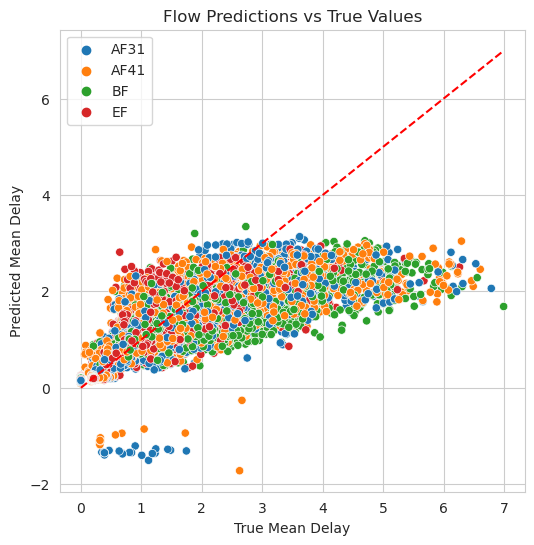

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: true vs predicted
plt.figure(figsize=(6,6))
sns.scatterplot(x="mean_delay", y="mean_delay_pred", hue="dscp_tag", data=df_flows)
plt.plot([df_flows["mean_delay"].min(), df_flows["mean_delay"].max()],
         [df_flows["mean_delay"].min(), df_flows["mean_delay"].max()], "r--")  # y=x line
plt.xlabel("True Mean Delay")
plt.ylabel("Predicted Mean Delay")
plt.title("Flow Predictions vs True Values")
plt.legend()
plt.show()


Extract links

Do everything in one pass per experiment: extract flows, links, queues, merge the relevant features (flows joined with their traversed link + queue info), and then append the merged DataFrame to a list. Finally, we can stack all experiments together

In [77]:
df_flows.columns

Index(['graph_id', 'src_node_flow', 'dst_node_flow', 'traffic_type',
       'dscp_tag', 'traffic_type_mapped', 'dscp_tag_dec', 'duration_p0',
       'duration_p25', 'duration_p50',
       ...
       'mean_tx_bit_rate_max', 'mean_tx_bit_rate_min', 'mean_delay',
       'mean_jitter', 'mean_tx_bit_rate', 'bandwidth_pct_%', 'nflow_id',
       'traversed_links', 'mean_delay_pred', 'traversed_link'],
      dtype='object', length=105)

In [98]:
import tarfile
import json
import pandas as pd
from pathlib import Path
from tqdm import tqdm

dataeval_path = Path("dataTest/train")
all_flows_merged = []  # store merged flows for all experiments

for tar_file in tqdm(dataeval_path.glob("*.tar*"), desc="Processing experiments"):
    with tarfile.open(tar_file, "r:*") as tar:
        # Find the JSON file inside
        json_members = [m for m in tar.getmembers() if m.name.endswith("data.json")]
        for member in json_members:
            f = tar.extractfile(member)
            if f:
                graph_list = json.load(f)  # list of graphs
                
                for g_idx, graph in enumerate(graph_list):
                    # Separate nodes by entity type
                    flows_records, links_records, queues_records = [], [], []
                    
                    for node in graph["nodes"]:
                        if node["entity"] == "flow":
                            features = {k: v for k, v in node.items() if k not in ["labels", "entity", "id"]}
                            labels = node.get("labels", {})
                            flows_records.append({**features, **labels, "graph_id": g_idx})
                        elif node["entity"] == "link":
                            links_records.append(node)
                        elif node["entity"] == "queue":
                            queues_records.append(node)
                    
                    # Build DataFrames
                    df_flows = pd.DataFrame(flows_records)
                    df_links = pd.DataFrame(links_records)
                    df_queues = pd.DataFrame(queues_records)
                    
                    # If traversed_links is list of 1 element, convert to scalar
                    if "traversed_links" in df_flows.columns:
                        df_flows["traversed_link"] = df_flows["traversed_links"].apply(lambda x: x[0] if isinstance(x, list) else x)

                    Child_size_num=df_queues['Child_size_num'].iloc[0]
                    Child_name=df_queues['Child_name'].iloc[0]
                    links_subset = df_links[['srcNode', 'device_id', 'datarate_bps', 'delay_s']].copy()
                    #queues_subset = df_queues[['source_node', 'device_paired', 'band_id', 'Child_size_num','Child_name']].copy()
                    flows_subest =df_flows[['src_node_flow', "traversed_link",'nflow_id', 'traffic_type',
                    'dscp_tag','mean_delay']].copy()
                    
                    links_subset['srcNode'] = links_subset['srcNode'].astype(int)
                    links_subset['device_id'] = links_subset['device_id'].astype(int)
                    #queues_subset['source_node'] = queues_subset['source_node'].astype(int)
                    #queues_subset['device_paired'] = queues_subset['device_paired'].astype(int)
                    flows_subest['src_node_flow'] = flows_subest['src_node_flow'].astype(int)
                    
                    # Merge links and queues first (on link identifiers)
                    '''
                    merged_links_queues = pd.merge(
                        links_subset,
                        queues_subset,
                        left_on=["srcNode", "device_id"],
                        right_on=["source_node", "device_paired"],
                        how="left"
                    )
                    merged_links_queues.drop(columns=['source_node','device_paired'],inplace=True)
                  '''
                  
                    # Merge flows with links+queues
                    merged_all = pd.merge(
                        flows_subest,
                        links_subset,
                        left_on=["src_node_flow", "traversed_link"],
                        right_on=["srcNode", "device_id"],
                        how="left"
                    )
                    
                    merged_all['Child_size_num']=Child_size_num
                    merged_all['Child_name']=Child_name
                    all_flows_merged.append(merged_all)

# Stack all experiments into one DataFrame
df_flows_all = pd.concat(all_flows_merged, ignore_index=True)
print(df_flows_all.shape)



Processing experiments: 0it [00:00, ?it/s]

Processing experiments: 7it [00:08,  1.16s/it]

(19488, 12)


In [99]:
df_flows_all.head(10)

,src_node_flow,traversed_link,nflow_id,traffic_type,dscp_tag,mean_delay,srcNode,device_id,datarate_bps,delay_s,Child_size_num,Child_name
0,0,3,1,FTP,AF31,0.000000,0,3,20000,0.16,10,ns3::RedQueueDisc
1,0,3,1,FTP,AF41,0.000000,0,3,20000,0.16,10,ns3::RedQueueDisc
2,0,3,4,FTP,BF,2.597826,0,3,20000,0.16,10,ns3::RedQueueDisc
3,0,1,1,FTP,EF,1.497700,0,1,20000,0.16,10,ns3::RedQueueDisc
4,0,3,3,GAMING,AF31,0.000000,0,3,20000,0.16,10,ns3::RedQueueDisc
5,0,3,21,GAMING,AF41,0.000000,0,3,20000,0.16,10,ns3::RedQueueDisc
6,0,3,3,GAMING,BF,1.901730,0,3,20000,0.16,10,ns3::RedQueueDisc
7,0,1,3,GAMING,EF,1.324668,0,1,20000,0.16,10,ns3::RedQueueDisc
8,0,3,21,VIDEO,AF31,0.407390,0,3,20000,0.16,10,ns3::RedQueueDisc
9,0,3,3,VIDEO,AF41,0.000000,0,3,20000,0.16,10,ns3::RedQueueDisc


In [100]:
df_flows_all["mean_delay_pred"] = mean_delay_preds

In [103]:
df_flows_all[['nflow_id','traffic_type','dscp_tag','mean_delay','mean_delay_pred']]

,nflow_id,traffic_type,dscp_tag,mean_delay,mean_delay_pred
0,1,FTP,AF31,0.000000,0.223084
1,1,FTP,AF41,0.000000,0.223084
2,4,FTP,BF,2.597826,1.670609
3,1,FTP,EF,1.497700,2.155118
4,3,GAMING,AF31,0.000000,0.235022
...,...,...,...,...,...
19483,3,VIDEO,EF,0.224148,0.197590
19484,3,VOIP,AF31,0.193766,0.196398
19485,3,VOIP,AF41,0.190923,0.192360
19486,14,VOIP,BF,0.206190,0.193003


perform post-training analysis to see how QoS parameters (like queue type, link datarate, link delay) affect the flows’ performance, grouped by traffic_type and dscp_tag

In [105]:
agg_cols = [
    "mean_delay","mean_delay_pred"
]

grouped = df_flows_all.groupby(["traffic_type", "dscp_tag"]).agg(
    {col: ["mean", "median", "std"] for col in agg_cols}
).reset_index()

# Flatten multi-index columns
grouped.columns = ["_".join(filter(None, col)).rstrip("_") for col in grouped.columns.values]

grouped.head()


,traffic_type,dscp_tag,mean_delay_mean,mean_delay_median,mean_delay_std,mean_delay_pred_mean,mean_delay_pred_median,mean_delay_pred_std
0,FTP,AF31,0.956248,0.296000,1.208791,0.780068,0.243622,0.830270
1,FTP,AF41,0.958320,0.311280,1.147659,0.839102,0.254319,0.841186
2,FTP,BF,1.268790,0.319167,1.357211,0.941046,0.250704,0.858484
3,FTP,EF,1.116472,0.397813,1.187803,0.958429,0.251019,0.876197
4,GAMING,AF31,0.876603,0.243573,1.104237,0.682524,0.236218,0.696443


In [106]:
agg_cols_qos = ["mean_delay","mean_delay_pred"]
grouped_qos = df_flows_all.groupby(
    ["traffic_type", "dscp_tag", "Child_name", "Child_size_num", "datarate_bps", "delay_s"]
).agg(
    {col: ["mean", "median", "std"] for col in agg_cols_qos}
).reset_index()

grouped_qos.columns = ["_".join(filter(None, col)).rstrip("_") for col in grouped_qos.columns.values]
grouped_qos.head()


,traffic_type,dscp_tag,Child_name,Child_size_num,datarate_bps,delay_s,mean_delay_mean,mean_delay_median,mean_delay_std,mean_delay_pred_mean,mean_delay_pred_median,mean_delay_pred_std
0,FTP,AF31,ns3::CoDelQueueDisc,10,20000,0.16,1.293736,0.340453,1.518473,0.939746,0.257994,0.955381
1,FTP,AF31,ns3::CoDelQueueDisc,10,20000,0.18,1.124437,0.336480,1.468767,0.844527,0.248410,0.967143
2,FTP,AF31,ns3::CoDelQueueDisc,10,50000,0.16,0.860058,0.291760,0.914414,0.817462,0.256351,0.709840
3,FTP,AF31,ns3::CoDelQueueDisc,10,50000,0.18,0.765654,0.244747,0.813468,0.728712,0.249132,0.681828
4,FTP,AF31,ns3::FifoQueueDisc,10,20000,0.16,0.906184,0.311040,1.295150,0.727039,0.236623,0.926746


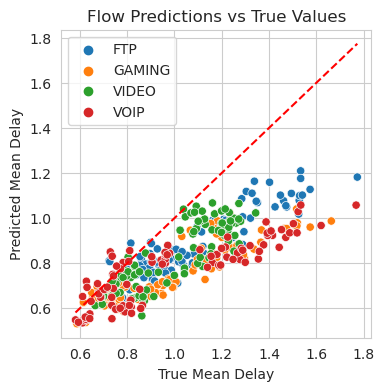

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: true vs predicted
plt.figure(figsize=(4,4))
sns.scatterplot(x="mean_delay_mean", y="mean_delay_pred_mean", hue="traffic_type", data=grouped_qos)
plt.plot([grouped_qos["mean_delay_mean"].min(), grouped_qos["mean_delay_mean"].max()],
         [grouped_qos["mean_delay_mean"].min(), grouped_qos["mean_delay_mean"].max()], "r--")  # y=x line
plt.xlabel("True Mean Delay")
plt.ylabel("Predicted Mean Delay")
plt.title("Flow Predictions vs True Values")
plt.legend()
plt.show()


For each traffic type and DSCP tag, the combination of queue, link bandwidth, and link delay that minimizes predicted flow delay

In [121]:
# Find the QoS combination with minimum predicted delay per traffic_type and dscp_tag
best_qos = grouped_qos.loc[grouped_qos.groupby(["traffic_type", "dscp_tag"])["mean_delay_pred_mean"].idxmin()]
best_qos = best_qos.reset_index(drop=True)
best_qos[['traffic_type', 'dscp_tag', 'Child_name', 'Child_size_num',
       'datarate_bps', 'delay_s', 'mean_delay_mean','mean_delay_pred_mean']]


,traffic_type,dscp_tag,Child_name,Child_size_num,datarate_bps,delay_s,mean_delay_mean,mean_delay_pred_mean
0,FTP,AF31,ns3::PieQueueDisc,10,20000,0.18,0.781173,0.639898
1,FTP,AF41,ns3::PieQueueDisc,10,50000,0.16,0.802794,0.729637
2,FTP,BF,ns3::TbfQueueDisc,10,50000,0.16,1.013768,0.712211
3,FTP,EF,ns3::TbfQueueDisc,10,50000,0.16,0.837397,0.747978
4,GAMING,AF31,ns3::PieQueueDisc,10,50000,0.18,0.587804,0.531980
5,GAMING,AF41,ns3::CoDelQueueDisc,10,50000,0.16,0.614482,0.625034
6,GAMING,BF,ns3::RedQueueDisc,10,50000,0.16,0.897286,0.654161
7,GAMING,EF,ns3::RedQueueDisc,10,50000,0.18,0.771890,0.647812
8,VIDEO,AF31,ns3::FifoQueueDisc,10,50000,0.16,0.757149,0.721445
9,VIDEO,AF41,ns3::PfifoFastQueueDisc,10,50000,0.18,0.968224,0.712907


rank all combinations for a given traffic type and DSCP

In [126]:
grouped_qos["rank"] = grouped_qos.groupby(["traffic_type", "dscp_tag"])["mean_delay_pred_mean"].rank(method="min")
top_combinations = grouped_qos[grouped_qos["rank"] <= 5]  # top 5
top_combinations[['traffic_type', 'dscp_tag', 'Child_name', 'Child_size_num',
       'datarate_bps', 'delay_s', 'mean_delay_mean','mean_delay_pred_mean']]


,traffic_type,dscp_tag,Child_name,Child_size_num,datarate_bps,delay_s,mean_delay_mean,mean_delay_pred_mean
8,FTP,AF31,ns3::PfifoFastQueueDisc,10,20000,0.16,0.911711,0.725851
13,FTP,AF31,ns3::PieQueueDisc,10,20000,0.18,0.781173,0.639898
14,FTP,AF31,ns3::PieQueueDisc,10,50000,0.16,0.810671,0.682405
15,FTP,AF31,ns3::PieQueueDisc,10,50000,0.18,0.896559,0.692746
19,FTP,AF31,ns3::RedQueueDisc,10,50000,0.18,0.781048,0.646424
...,...,...,...,...,...,...,...,...
362,VOIP,EF,ns3::CoDelQueueDisc,10,50000,0.16,0.605160,0.536655
366,VOIP,EF,ns3::FifoQueueDisc,10,50000,0.16,0.611654,0.535953
367,VOIP,EF,ns3::FifoQueueDisc,10,50000,0.18,0.627141,0.548444
370,VOIP,EF,ns3::PfifoFastQueueDisc,10,50000,0.16,0.615405,0.548645


the average predicted delay per single parameter, keeping others aggregated:

In [129]:
# Average delay per queue type
grouped_qos.groupby("Child_name")["mean_delay_pred_mean"].mean().sort_values()



Child_name
ns3::PieQueueDisc          0.789304
ns3::CoDelQueueDisc        0.804627
ns3::FifoQueueDisc         0.810367
ns3::PfifoFastQueueDisc    0.810422
ns3::TbfQueueDisc          0.822481
ns3::RedQueueDisc          0.826931
Name: mean_delay_pred_mean, dtype: float32

In [ ]:
# Average delay per link bandwidth
grouped_qos.groupby("datarate_bps")["mean_delay_pred_mean"].mean().sort_values()

datarate_bps
50000    0.705121
20000    0.916257
Name: mean_delay_pred_mean, dtype: float32